# 3. 텍스트 데이터의 특징

In [1]:
!pip install gensim==4.3.2
!conda install scipy==1.12.0 numpy==1.26.3 -y

/bin/bash: line 1: conda: command not found


In [2]:
# 처리해야 할 문장을 파이썬 리스트에 옮겨 담았습니다.
sentences=['i feel hungry', 'i eat lunch', 'now i feel happy']

# 파이썬 split() 메소드를 이용해 단어 단위로 문장을 쪼개 봅니다.
word_list = 'i feel hungry'.split()
print(word_list)

['i', 'feel', 'hungry']


In [3]:
index_to_word={}  # 빈 딕셔너리를 만들어서

# 단어들을 하나씩 채워 봅니다. 채우는 순서는 일단 임의로 하였습니다. 그러나 사실 순서는 중요하지 않습니다.
# <BOS>, <PAD>, <UNK>는 관례적으로 딕셔너리 맨 앞에 넣어줍니다.
index_to_word[0]='<PAD>'  # 패딩용 단어
index_to_word[1]='<BOS>'  # 문장의 시작지점
index_to_word[2]='<UNK>'  # 사전에 없는(Unknown) 단어
index_to_word[3]='i'
index_to_word[4]='feel'
index_to_word[5]='hungry'
index_to_word[6]='eat'
index_to_word[7]='lunch'
index_to_word[8]='now'
index_to_word[9]='happy'

print(index_to_word)

{0: '<PAD>', 1: '<BOS>', 2: '<UNK>', 3: 'i', 4: 'feel', 5: 'hungry', 6: 'eat', 7: 'lunch', 8: 'now', 9: 'happy'}


In [4]:
word_to_index={word:index for index, word in index_to_word.items()}
print(word_to_index)

{'<PAD>': 0, '<BOS>': 1, '<UNK>': 2, 'i': 3, 'feel': 4, 'hungry': 5, 'eat': 6, 'lunch': 7, 'now': 8, 'happy': 9}


In [5]:
print(word_to_index['feel'])  # 단어 'feel'은 숫자 인덱스 4로 바뀝니다.

4


In [6]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트로 변환해 주는 함수를 만들어 봅시다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

print(get_encoded_sentence('i eat lunch', word_to_index))

[1, 3, 6, 7]


In [7]:
# 여러 개의 문장 리스트를 한꺼번에 숫자 텐서로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# sentences=['i feel hungry', 'i eat lunch', 'now i feel happy'] 가 아래와 같이 변환됩니다.
encoded_sentences = get_encoded_sentences(sentences, word_to_index)
print(encoded_sentences)

[[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]]


In [8]:
# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

print(get_decoded_sentence([1, 3, 4, 5], index_to_word))

i feel hungry


In [9]:
# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

# encoded_sentences=[[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]] 가 아래와 같이 변환됩니다.
print(get_decoded_sentences(encoded_sentences, index_to_word))

['i feel hungry', 'i eat lunch', 'now i feel happy']


In [10]:
# 아래 코드는 그대로 실행하시면 에러가 발생할 것입니다.

import torch
import torch.nn as nn
import numpy as np
import os

vocab_size = len(word_to_index)  # 위 예시에서 딕셔너리에 포함된 단어 개수는 10
word_vector_dim = 4    # 위 그림과 같이 4차원의 워드 벡터를 가정합니다.

embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=word_vector_dim, padding_idx=0)

# 숫자로 변환된 텍스트 데이터 [[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]] 에 Embedding 레이어를 적용합니다.
raw_inputs = np.array(get_encoded_sentences(sentences, word_to_index), dtype='object')
raw_inputs_tensor = torch.tensor(raw_inputs, dtype=torch.long)
output = embedding(raw_inputs_tensor)
print(output)

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [16]:
import torch.nn.functional as F

raw_inputs = [torch.tensor(sentence, dtype=torch.long) for sentence in raw_inputs]
raw_inputs = torch.nn.utils.rnn.pad_sequence(raw_inputs, batch_first=True, padding_value=word_to_index['<PAD>'])
print(raw_inputs)

tensor([[1, 3, 4, 5, 0],
        [1, 3, 6, 7, 0],
        [1, 8, 3, 4, 9]])


In [17]:
vocab_size = len(word_to_index)   # 위 예시에서 딕셔너리에 포함된 단어 개수는 10
word_vector_dim = 4   # 그림과 같이 4차원의 워드 벡터를 가정합니다.

embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=word_to_index['<PAD>'])

# nn.Embedding를 통해 word vector를 모두 일정 길이로 맞춰주어야
# embedding 레이어의 input이 될 수 있음에 주의해 주세요.
encoded_sentences = get_encoded_sentences(sentences, word_to_index)
maxlen = 5
padded_sentences = [sentence + [word_to_index['<PAD>']] * (maxlen - len(sentence)) if len(sentence) < maxlen else sentence[:maxlen] for sentence in encoded_sentences]

raw_inputs = torch.tensor(padded_sentences, dtype=torch.long)
output = embedding(raw_inputs)
print(output)

tensor([[[-0.3448,  0.8737,  0.8244,  0.0029],
         [-0.1413, -0.3491, -1.7240, -1.2359],
         [-0.0429, -0.0936, -0.0154, -1.0128],
         [ 0.5995,  0.0227, -0.6400, -0.6642],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[-0.3448,  0.8737,  0.8244,  0.0029],
         [-0.1413, -0.3491, -1.7240, -1.2359],
         [-0.2620, -0.1172,  0.0682,  1.0930],
         [-1.9444, -1.1483, -0.3520, -0.6144],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[-0.3448,  0.8737,  0.8244,  0.0029],
         [ 0.2041,  0.8981, -0.8379, -0.9990],
         [-0.1413, -0.3491, -1.7240, -1.2359],
         [-0.0429, -0.0936, -0.0154, -1.0128],
         [ 0.9450,  1.3204, -0.1416, -0.4562]]], grad_fn=<EmbeddingBackward0>)


# 4. 시퀀스 데이터를 다루는 RNN

In [18]:
class Model_1(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_1, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)   # 가장 널리 쓰이는 RNN인 LSTM 레이어를 사용하였습니다. 이때 LSTM state 벡터의 차원수는 8로 하였습니다. (변경 가능)
        self.fc1 = nn.Linear(8, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10   # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원수입니다.
model = Model_1(vocab_size, word_vector_dim)

print(model)

Model_1(
  (embedding): Embedding(10, 4)
  (lstm): LSTM(4, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# 5. 꼭 RNN이어야 할까?

In [19]:
class Model_2(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_2, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=7)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=7)
        self.pool = nn.MaxPool1d(5)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10    # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_2(vocab_size, word_vector_dim)

print(model)

Model_2(
  (embedding): Embedding(10, 4)
  (conv1): Conv1d(4, 16, kernel_size=(7,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(7,), stride=(1,))
  (pool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [20]:
class Model_3(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_3, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(word_vector_dim, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10   # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_3(vocab_size, word_vector_dim)

print(model)

Model_3(
  (embedding): Embedding(10, 4)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# 6. IMDB 영화리뷰 감성분석

## (1) IMDB 데이터셋 분석

In [21]:
import tensorflow as tf
imdb = tf.keras.datasets.imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print(f"훈련 샘플 개수: {len(x_train)}, 테스트 개수: {len(x_test)}")

훈련 샘플 개수: 25000, 테스트 개수: 25000


In [22]:
print(x_train[0])  # 1번째 리뷰데이터
print('라벨: ', y_train[0])  # 1번째 리뷰데이터의 라벨
print('1번째 리뷰 문장 길이: ', len(x_train[0]))
print('2번째 리뷰 문장 길이: ', len(x_train[1]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
라벨:  1
1번째 리뷰 문장 길이:  218
2번째 리뷰 문장 길이:  189


In [23]:
# word_to_index = imdb.get_word_index()
word_to_index = imdb.get_word_index()
index_to_word = {index:word for word, index in word_to_index.items()}
print(index_to_word[1])     # 'the' 가 출력됩니다.
print(word_to_index['the'])  # 1 이 출력됩니다.

the
1


In [24]:
print(get_decoded_sentence(x_train[0], index_to_word))

as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other and in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then have two of

In [25]:
#실제 인코딩 인덱스는 제공된 word_to_index에서 index 기준으로 3씩 뒤로 밀려 있습니다.
word_to_index = {k:(v+3) for k,v in word_to_index.items()}

# 처음 몇 개 인덱스는 사전에 정의되어 있습니다.
word_to_index["<PAD>"] = 0
word_to_index["<BOS>"] = 1
word_to_index["<UNK>"] = 2  # unknown
word_to_index["<UNUSED>"] = 3

index_to_word = {index:word for word, index in word_to_index.items()}

print(index_to_word[1])     # '<BOS>' 가 출력됩니다.
print(word_to_index['the'])  # 4 이 출력됩니다.
print(index_to_word[4])     # 'the' 가 출력됩니다.

# 보정 후 x_train[0] 데이터
print(get_decoded_sentence(x_train[0], index_to_word))

<BOS>
4
the
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for

In [26]:
print(get_decoded_sentence(x_train[0], index_to_word))
print('라벨: ', y_train[0])  # 1번째 리뷰데이터의 라벨

this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they h

In [27]:
total_data_text = list(x_train) + list(x_test)
# 텍스트데이터 문장길이의 리스트를 생성한 후
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)
# 문장길이의 평균값, 최대값, 표준편차를 계산해 본다.
print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 예를들어, 최대 길이를 (평균 + 2*표준편차)로 한다면,
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens)}%가 maxlen 설정값 이내에 포함됩니다. ')

문장길이 평균 :  234.75892
문장길이 최대 :  2494
문장길이 표준편차 :  172.91149458735703
pad_sequences maxlen :  580
전체 문장의 0.94536%가 maxlen 설정값 이내에 포함됩니다. 


In [28]:
def pad_sequences(data, maxlen):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = sentence + [0] * (maxlen - len(sentence))
        else:
            sentence = sentence[:maxlen]
        padded_data.append(sentence)
    return np.array(padded_data)

x_train_padded = pad_sequences(x_train, maxlen)
x_test_padded = pad_sequences(x_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print(x_train_tensor.shape)

torch.Size([25000, 580])


## (2) 딥러닝 모델 설계와 훈련

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

vocab_size = 10000    # 어휘 사전의 크기입니다(10,000개의 단어)
word_vector_dim = 16  # 워드 벡터의 차원 수 (변경 가능한 하이퍼파라미터)

# model 설계 - 딥러닝 모델 코드를 직접 작성해 주세요.
class SentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8, batch_first=True)
        self.fc1 = nn.Linear(8, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SentimentModel(vocab_size, word_vector_dim)
print(model)

SentimentModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc1): Linear(in_features=8, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [30]:
# validation set 10000건 분리
x_val = x_train_tensor[:10000]
y_val = y_train[:10000]

# validation set을 제외한 나머지 15000건
partial_x_train = x_train_tensor[10000:]
partial_y_train = y_train[10000:]

print(partial_x_train.shape)
print(partial_y_train.shape)

torch.Size([15000, 580])
(15000,)


In [31]:
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

optimizer = optim.Adam(model.parameters())
loss_fn = torch.nn.BCELoss()

partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

epochs = 30   # 몇 epoch를 훈련하면 좋을지 결과를 보면서 바꾸어 봅시다.
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (outputs.squeeze() > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)

            val_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accs[-1]:.4f} - "
          f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accs[-1]:.4f}")

/tmp/ipython-input-1424571675.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
/tmp/ipython-input-1424571675.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_val_tensor = torch.tensor(x_val, dtype=torch.long)


Epoch 1/30 - Train Loss: 0.6933, Train Accuracy: 0.5039 - Validation Loss: 0.6932, Validation Accuracy: 0.4968
Epoch 2/30 - Train Loss: 0.6930, Train Accuracy: 0.5076 - Validation Loss: 0.6934, Validation Accuracy: 0.4978
Epoch 3/30 - Train Loss: 0.6930, Train Accuracy: 0.5095 - Validation Loss: 0.6933, Validation Accuracy: 0.4990
Epoch 4/30 - Train Loss: 0.6929, Train Accuracy: 0.5105 - Validation Loss: 0.6933, Validation Accuracy: 0.4994
Epoch 5/30 - Train Loss: 0.6928, Train Accuracy: 0.5105 - Validation Loss: 0.6932, Validation Accuracy: 0.5003
Epoch 6/30 - Train Loss: 0.6927, Train Accuracy: 0.5102 - Validation Loss: 0.6932, Validation Accuracy: 0.5003
Epoch 7/30 - Train Loss: 0.6926, Train Accuracy: 0.5104 - Validation Loss: 0.6931, Validation Accuracy: 0.5005
Epoch 8/30 - Train Loss: 0.6925, Train Accuracy: 0.5105 - Validation Loss: 0.6931, Validation Accuracy: 0.5002
Epoch 9/30 - Train Loss: 0.6923, Train Accuracy: 0.5111 - Validation Loss: 0.6932, Validation Accuracy: 0.5001
E

In [32]:
test_dataset = TensorDataset(x_test_tensor, torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        test_loss += loss.item()
        predicted = (outputs.squeeze() > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.7060, Test Accuracy: 0.5044


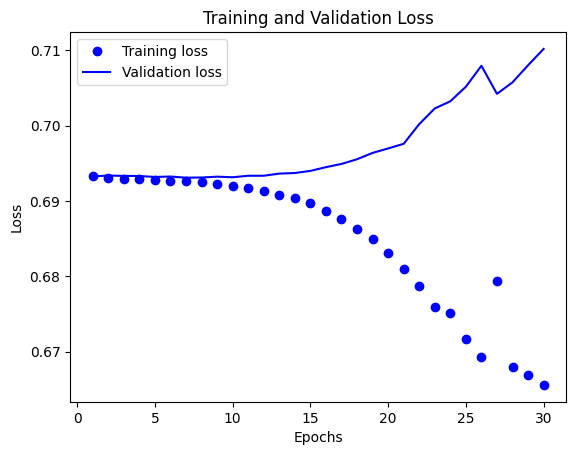

In [33]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

# "bo"는 "파란색 점"입니다
plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
# b는 "파란 실선"입니다
plt.plot(epochs_range, val_losses, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

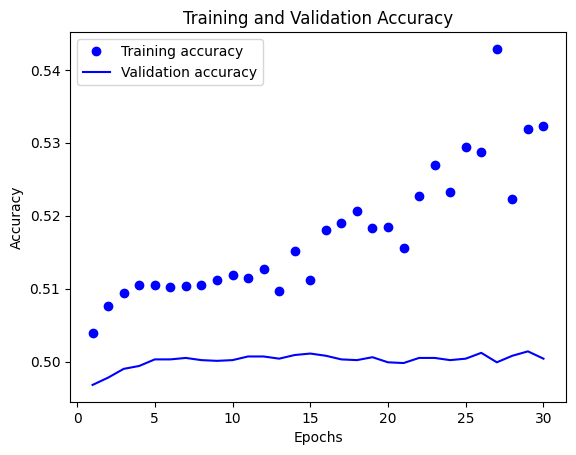

In [34]:
plt.clf()   # 그림을 초기화합니다

plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accs, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## (3) Word2Vec의 적용

In [35]:
!pip install scipy==1.12.0

In [36]:
embedding_layer = model.embedding
weights = embedding_layer.weight.detach().cpu().numpy()

print(weights.shape)  # shape: (vocab_size, embedding_dim)

(10000, 16)


In [37]:
word2vec_file_path = 'word2vec.txt'

with open(word2vec_file_path, 'w', encoding='utf-8') as f:
    f.write('{} {}\n'.format(vocab_size - 4, word_vector_dim))   # 몇개의 벡터를 얼마 사이즈로 기재할지 타이틀을 씁니다.

    # 단어 개수(에서 특수문자 4개는 제외하고)만큼의 워드 벡터를 파일에 기록합니다.
    vectors = model.embedding.weight.detach().cpu().numpy()
    for i in range(4, vocab_size):
        f.write('{} {}\n'.format(index_to_word[i], ' '.join(map(str, vectors[i, :]))))

In [38]:
from gensim.models.keyedvectors import Word2VecKeyedVectors

word_vectors = Word2VecKeyedVectors.load_word2vec_format(word2vec_file_path, binary=False)

vector = word_vectors['computer']

vector

array([ 0.2827276 , -0.6495409 , -2.022458  ,  0.32376936,  0.44450006,
        0.42798042, -1.4481453 , -1.0028083 , -2.234589  , -0.03685521,
        1.0616422 , -1.1261271 , -0.6737812 , -1.1515477 ,  0.06794428,
        1.1746683 ], dtype=float32)

In [39]:
word_vectors.similar_by_word("love")

[('video', 0.8662514090538025),
 ('hype', 0.7634363770484924),
 ('arrest', 0.7436748147010803),
 ('tight', 0.7327960729598999),
 ('accepting', 0.7260141968727112),
 ('spacey', 0.7195332050323486),
 ('guilt', 0.7128785252571106),
 ('wasted', 0.7082039713859558),
 ('needs', 0.7030229568481445),
 ('release', 0.7025896906852722)]

In [40]:
from gensim.models import KeyedVectors

word2vec_path = 'GoogleNews-vectors-negative300.bin.gz'
word2vec = KeyedVectors.load_word2vec_format(word2vec_path, binary=True, limit=1000000)
vector = word2vec['computer']
vector

array([ 1.07421875e-01, -2.01171875e-01,  1.23046875e-01,  2.11914062e-01,
       -9.13085938e-02,  2.16796875e-01, -1.31835938e-01,  8.30078125e-02,
        2.02148438e-01,  4.78515625e-02,  3.66210938e-02, -2.45361328e-02,
        2.39257812e-02, -1.60156250e-01, -2.61230469e-02,  9.71679688e-02,
       -6.34765625e-02,  1.84570312e-01,  1.70898438e-01, -1.63085938e-01,
       -1.09375000e-01,  1.49414062e-01, -4.65393066e-04,  9.61914062e-02,
        1.68945312e-01,  2.60925293e-03,  8.93554688e-02,  6.49414062e-02,
        3.56445312e-02, -6.93359375e-02, -1.46484375e-01, -1.21093750e-01,
       -2.27539062e-01,  2.45361328e-02, -1.24511719e-01, -3.18359375e-01,
       -2.20703125e-01,  1.30859375e-01,  3.66210938e-02, -3.63769531e-02,
       -1.13281250e-01,  1.95312500e-01,  9.76562500e-02,  1.26953125e-01,
        6.59179688e-02,  6.93359375e-02,  1.02539062e-02,  1.75781250e-01,
       -1.68945312e-01,  1.21307373e-03, -2.98828125e-01, -1.15234375e-01,
        5.66406250e-02, -

In [41]:
word2vec.similar_by_word("love")

[('loved', 0.6907791495323181),
 ('adore', 0.6816873550415039),
 ('loves', 0.661863386631012),
 ('passion', 0.6100708842277527),
 ('hate', 0.600395679473877),
 ('loving', 0.5886635780334473),
 ('affection', 0.5664337873458862),
 ('undying_love', 0.5547304749488831),
 ('absolutely_adore', 0.5536840558052063),
 ('adores', 0.5440906882286072)]

In [42]:
vocab_size = 10000    # 어휘 사전의 크기입니다(10,000개의 단어)
word_vector_dim = 300  # 워드 벡터의 차원수
embedding_matrix = np.random.rand(vocab_size, word_vector_dim)

# embedding_matrix에 Word2Vec 워드 벡터를 단어 하나씩마다 차례차례 카피한다.
for i in range(4,vocab_size):
    if index_to_word[i] in word2vec:
        embedding_matrix[i] = word2vec[index_to_word[i]]

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, embedding_matrix, maxlen):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)    # 카피한 임베딩을 여기서 활용
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.conv1 = nn.Conv1d(in_channels=word_vector_dim, out_channels=16, kernel_size=7)
        self.pool = nn.MaxPool1d(kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=7)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.global_max_pool(x).squeeze(2)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

vocab_size = 10000    # 어휘 사전의 크기입니다(10,000개의 단어)
word_vector_dim = 300  # 워드 벡터의 차원 수

embedding_matrix = torch.randn(vocab_size, word_vector_dim)

model = SentimentModel(vocab_size, word_vector_dim, embedding_matrix, maxlen)
print(model)

SentimentModel(
  (embedding): Embedding(10000, 300)
  (conv1): Conv1d(300, 16, kernel_size=(7,), stride=(1,))
  (pool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 16, kernel_size=(7,), stride=(1,))
  (global_max_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


/tmp/ipython-input-1688845905.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))


In [44]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.BCELoss()

partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

# 학습의 진행
epochs = 20    # 몇 epoch를 훈련하면 좋을지 결과를 보면서 바꾸어 봅시다.
train_losses = []
val_losses = []
train_accs = []
val_accs = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # cuda 또는 cpu 출력
model.to(device)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (outputs.squeeze() > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)

            val_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accs[-1]:.4f} - "
          f"Validation Loss: {val_losses[-1]:.4f}, Validation Accuracy: {val_accs[-1]:.4f}")

/tmp/ipython-input-630273488.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
/tmp/ipython-input-630273488.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_val_tensor = torch.tensor(x_val, dtype=torch.long)


cuda
Epoch 1/20 - Train Loss: 0.6951, Train Accuracy: 0.5101 - Validation Loss: 0.6898, Validation Accuracy: 0.5953
Epoch 2/20 - Train Loss: 0.6779, Train Accuracy: 0.6171 - Validation Loss: 0.6540, Validation Accuracy: 0.6484
Epoch 3/20 - Train Loss: 0.5740, Train Accuracy: 0.7165 - Validation Loss: 0.5011, Validation Accuracy: 0.7659
Epoch 4/20 - Train Loss: 0.4168, Train Accuracy: 0.8131 - Validation Loss: 0.4053, Validation Accuracy: 0.8171
Epoch 5/20 - Train Loss: 0.3043, Train Accuracy: 0.8769 - Validation Loss: 0.3718, Validation Accuracy: 0.8358
Epoch 6/20 - Train Loss: 0.2279, Train Accuracy: 0.9171 - Validation Loss: 0.3685, Validation Accuracy: 0.8434
Epoch 7/20 - Train Loss: 0.1740, Train Accuracy: 0.9401 - Validation Loss: 0.3633, Validation Accuracy: 0.8502
Epoch 8/20 - Train Loss: 0.1224, Train Accuracy: 0.9656 - Validation Loss: 0.3672, Validation Accuracy: 0.8549
Epoch 9/20 - Train Loss: 0.0845, Train Accuracy: 0.9819 - Validation Loss: 0.3944, Validation Accuracy: 0.8

In [45]:
# 테스트셋을 통한 모델 평가
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)

        test_loss += loss.item()
        predicted = (outputs.squeeze() > 0.5).float()
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f"Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_correct / test_total:.4f}")

Test Loss: 0.6550, Test Accuracy: 0.8426


# 12. 영화리뷰 텍스트 감성분석하기 [프로젝트]

## 1. 프로젝트 : 네이버 영화리뷰 감성분석 도전하기

In [46]:
%%capture
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
!mv -f ratings_*.txt ~/work/sentiment_classification/data
!pip install konlpy
!sudo apt-get install git
!sudo apt-get install curl
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [47]:
%%capture
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
%cd ..

In [70]:
import pandas
import konlpy
import gensim

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.2.2
0.6.0
4.3.2


## (1) 데이터 준비와 확인

In [71]:
import pandas as pd
import os

train_data = pd.read_table('/content/ratings_train.txt')
test_data = pd.read_table('/content/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## (2) 데이터로더 구성

In [72]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [73]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [74]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수
# 모든 문장은 <BOS>로 시작
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

## (3) 모델 구성을 위한 데이터 분석 및 가공

### (3)-1 문장길이 분포

문장 길이 평균 :  15.970999134837385
문장 길이 최대 :  116
문장 길이 표준편차 :  12.844062760401604


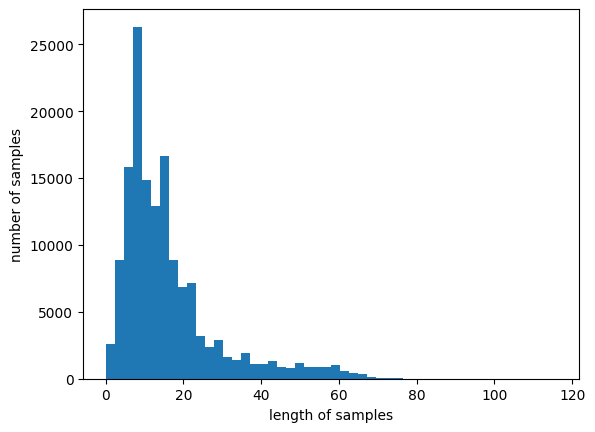

In [75]:
import matplotlib.pyplot as plt

# 모든 문장의 길이를 리스트화
total_data_len = [len(sentence) for sentence in X_train] + [len(sentence) for sentence in X_test]

# 통계치
import numpy as np
print('문장 길이 평균 : ', np.mean(total_data_len))
print('문장 길이 최대 : ', np.max(total_data_len))
print('문장 길이 표준편차 : ', np.std(total_data_len))

# 그래프 분포를 확인
plt.hist([len(s) for s in X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

### (3)-2 max_len 설정
정확성을 어느정도 챙기면서, 연산 효율성을 위해 테스트

In [77]:
# 실험 1: max_len을 평균 기준으로
max_len_1 = 16

# 길이를 측정
count_1 = sum(1 for sentence in X_train if len(sentence) <= max_len_1)
coverage_1 = (count_1 / len(X_train)) * 100

print("--- [실험 1 결과] ---")
print(f"설정 길이: {max_len_1}")
print(f"전체 샘플 중 포함되는 비율: {coverage_1:.2f}%")

--- [실험 1 결과] ---
설정 길이: 16
전체 샘플 중 포함되는 비율: 67.07%


In [78]:
# 실험 2: max_len을 아예 크게
max_len_2 = 70

count_2 = sum(1 for sentence in X_train if len(sentence) <= max_len_2)
coverage_2 = (count_2 / len(X_train)) * 100

print("--- [실험 2 결과] ---")
print(f"설정 길이: {max_len_2}")
print(f"전체 샘플 중 포함되는 비율: {coverage_2:.2f}%")

--- [실험 2 결과] ---
설정 길이: 70
전체 샘플 중 포함되는 비율: 99.89%


In [79]:
# 실험 3: 평균+(2 X 표준편차)
max_len_3 = 41

count_3 = sum(1 for sentence in X_train if len(sentence) <= max_len_3)
coverage_3 = (count_3 / len(X_train)) * 100

print("--- [실험 3 결과] ---")
print(f"설정 길이: {max_len_3}")
print(f"전체 샘플 중 포함되는 비율: {coverage_3:.2f}%")

--- [실험 3 결과] ---
설정 길이: 41
전체 샘플 중 포함되는 비율: 93.41%


In [80]:
# 2. 최대길이 설정
max_len = 41

def below_threshold_len(max_len, nested_list):
    cnt = 0
    for s in nested_list:
        if(len(s) <= max_len):
            cnt = cnt + 1
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))*100))

below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 41 이하인 샘플의 비율: 93.41300570521679


### (3)-3 torch.nn.utils.rnn.pad_sequence 을 활용한 패딩 추가

In [91]:
from torch.nn.utils.rnn import pad_sequence

def torch_rnn_pre_padding(X_list, max_len):
    # 1. 각 문장을 텐서로 변환하고 '뒤집기' (Flip)
    # 뒤집어서 넣으면 pad_sequence가 뒤에 0을 채울 때, 결과적으로는 '앞'에 채워짐.
    reversed_tensors = [torch.LongTensor(s[::-1] if isinstance(s, list) else s.flip(0)) for s in X_list]

    # 2. rnn.pad_sequence 실행 (뒤집힌 상태에서 뒤에 0이 붙음)
    padded = pad_sequence(reversed_tensors, batch_first=True, padding_value=0)

    # 3. 우리가 정한 max_len(41)로 길이 맞추기 (자르거나 늘리기)
    if padded.size(1) > max_len:
        padded = padded[:, :max_len]
    else:
        pad_size = max_len - padded.size(1)
        padded = torch.nn.functional.pad(padded, (0, pad_size), "constant", 0)

    # 4. 다시 원래대로 뒤집기 (Flip) -> 0이 앞으로 오게 됨
    return padded.flip(1)

X_train = torch_rnn_pre_padding(X_train, 41)
X_test = torch_rnn_pre_padding(X_test, 41)

print("Finish!")
print("Shape:", X_train.shape)
print(X_train[0])

Finish!
Shape: torch.Size([146182, 41])
tensor([  3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
          3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,   3,
          3,   3,   3,  32,  74, 939,   4,   4,  39, 229,  20,  33, 747])


## (4) 모델 구성 및 Validation set 구성

In [92]:
#Validation set 구성
# 전체 146,182개 중 약 20%인 30,000개를 검증셋으로 분리
x_val = X_train[:30000]
y_val = torch.FloatTensor(y_train[:30000]) # 라벨 텐서화

partial_x_train = X_train[30000:]
partial_y_train = torch.FloatTensor(y_train[30000:])

print(f"학습 데이터: {len(partial_x_train)}개")
print(f"검증 데이터: {len(x_val)}개")

학습 데이터: 116182개
검증 데이터: 30000개


###(4)-1 모델 1: LSTM

In [93]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.sigmoid(self.fc(hidden[-1]))

###(4)-2 모델2: CNN-1D

In [95]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv = nn.Conv1d(embedding_dim, num_filters, kernel_size=3)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(num_filters, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # (Batch, Len, Dim) -> (Batch, Dim, Len)으로 축 변경
        x = self.embedding(x).transpose(1, 2)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        return self.sigmoid(self.fc(x))

###(4)-3 모델3: GlobalMaxPooling1D

In [112]:
class GlobalMaxModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # 128차원의 특징을 1개로 압축 (문장에서 가장 강한 특징 추출)
        self.pool = nn.AdaptiveMaxPool1d(1)
        # 풀링 결과가 1이 되므로, 입력은 embedding_dim(128)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (Batch, Len)
        x = self.embedding(x).transpose(1, 2) # (Batch, Dim, Len)
        x = self.pool(x).squeeze(-1)          # (Batch, Dim)으로 압축
        x = self.fc(x)                        # (Batch, 1)
        return self.sigmoid(x).squeeze()      # (Batch)로 최종 압축해서 Loss와 크기 맞춤

디버깅 : AdaptiveMaxPool1d(1)로 가장 중요한 특징들만 남긴 뒤, Linear 레이어를 통해 최종적으로 하나의 점수로 합쳤음. 마지막에 .squeeze()를 붙여서 [64, 1] 형태를 정답지와 똑같은 [64] 형태로 만들어 줌

## 5. 모델 훈련

In [113]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 10000  # 단어 사전 크기
EMBEDDING_DIM = 128 # 단어 임베딩 차원
HIDDEN_DIM = 256    # 은닉층 노드 수
EPOCHS = 5          # 학습 횟수 (성능 비교를 위해 동일하게 설정)
LEARNING_RATE = 0.001

# 공통 손실 함수
criterion = nn.BCELoss()

###(5)-1 LSTM 모델 훈련

In [108]:
model_lstm = LSTMModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

print("[실험 1] LSTM 모델 훈련")
history_lstm = train_model(model_lstm, train_loader, val_loader, criterion, optimizer_lstm, epochs=EPOCHS)

[실험 1] LSTM 모델 훈련
Epoch 1/5 | Train Loss: 0.4182 | Val Loss: 0.3458 | Val Acc: 0.8476
Epoch 2/5 | Train Loss: 0.3052 | Val Loss: 0.3235 | Val Acc: 0.8608
Epoch 3/5 | Train Loss: 0.2473 | Val Loss: 0.3244 | Val Acc: 0.8647
Epoch 4/5 | Train Loss: 0.1873 | Val Loss: 0.3506 | Val Acc: 0.8621
Epoch 5/5 | Train Loss: 0.1264 | Val Loss: 0.4085 | Val Acc: 0.8590


###(5)-2 CNN모델 훈련

In [115]:
# CNN의 경우 하이퍼파라미터 명칭이 다를 수 있어 구조에 맞게 설정 (필터 수 128개)
model_cnn = CNNModel(VOCAB_SIZE, EMBEDDING_DIM, num_filters=128).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)

print("[실험 2] CNN 모델 훈련")
history_cnn = train_model(model_cnn, train_loader, val_loader, criterion, optimizer_cnn, epochs=EPOCHS)

[실험 2] CNN 모델 훈련
Epoch 1/5 | Train Loss: 0.4218 | Val Loss: 0.3589 | Val Acc: 0.8415
Epoch 2/5 | Train Loss: 0.3123 | Val Loss: 0.3398 | Val Acc: 0.8512
Epoch 3/5 | Train Loss: 0.2534 | Val Loss: 0.3529 | Val Acc: 0.8505
Epoch 4/5 | Train Loss: 0.1990 | Val Loss: 0.3943 | Val Acc: 0.8433
Epoch 5/5 | Train Loss: 0.1500 | Val Loss: 0.4418 | Val Acc: 0.8449


###(5)-3 GlobalMax모델 훈련

In [114]:
model_max = GlobalMaxModel(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
optimizer_max = optim.Adam(model_max.parameters(), lr=LEARNING_RATE)

print("[실험3] GlobalMax 모델 훈련")
history_max = train_model(model_max, train_loader, val_loader, criterion, optimizer_max, epochs=EPOCHS)

[실험3] GlobalMax 모델 훈련
Epoch 1/5 | Train Loss: 0.5416 | Val Loss: 0.4358 | Val Acc: 0.7963
Epoch 2/5 | Train Loss: 0.3986 | Val Loss: 0.3905 | Val Acc: 0.8221
Epoch 3/5 | Train Loss: 0.3519 | Val Loss: 0.3761 | Val Acc: 0.8330
Epoch 4/5 | Train Loss: 0.3229 | Val Loss: 0.3693 | Val Acc: 0.8382
Epoch 5/5 | Train Loss: 0.2995 | Val Loss: 0.3614 | Val Acc: 0.8425


## 6.Loss, Accuracy 그래프 시각화

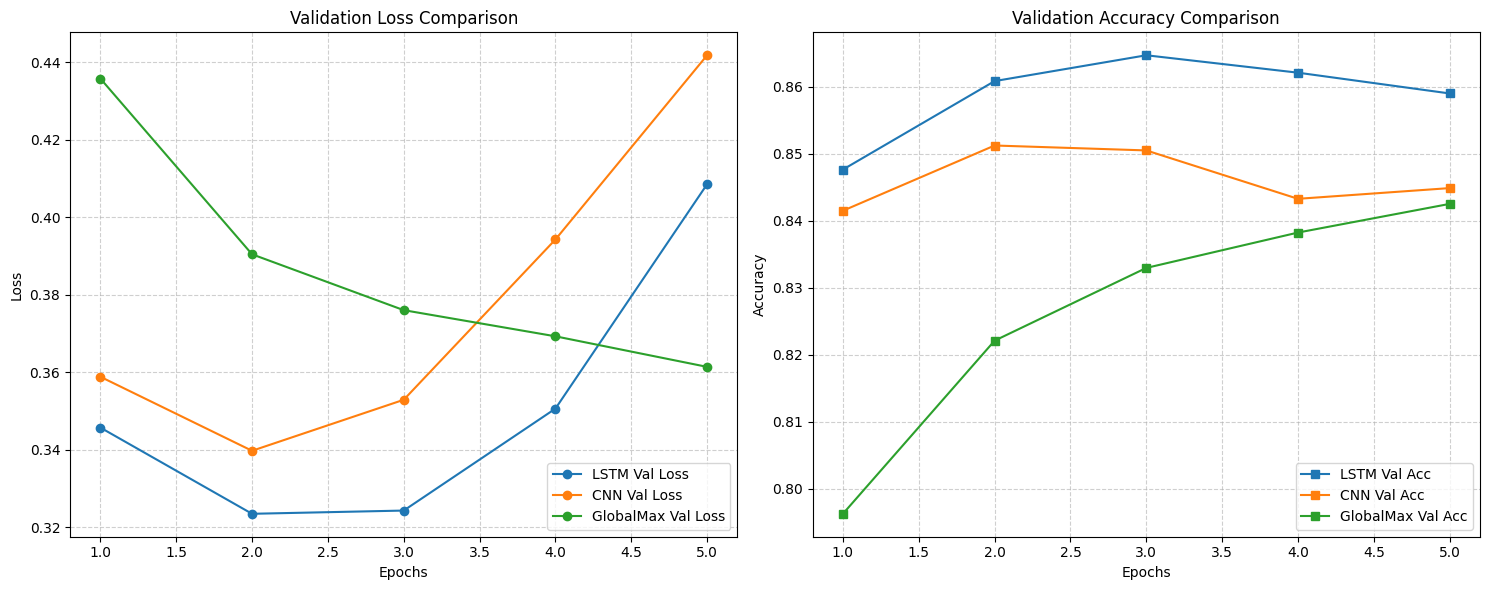

In [116]:
import matplotlib.pyplot as plt

def plot_all_histories(histories, names):

    epochs = range(1, len(histories[0]['train_loss']) + 1)
    plt.figure(figsize=(15, 6))

    # 1. Loss 비교 (Validation Loss 중심)
    plt.subplot(1, 2, 1)
    for hist, name in zip(histories, names):
        plt.plot(epochs, hist['val_loss'], label=f'{name} Val Loss', marker='o')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Accuracy 비교 (Validation Accuracy 중심)
    plt.subplot(1, 2, 2)
    for hist, name in zip(histories, names):
        plt.plot(epochs, hist['val_acc'], label=f'{name} Val Acc', marker='s')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# 3가지 모델 결과 통합 시각화
plot_all_histories(
    [history_lstm, history_cnn, history_max],
    ['LSTM', 'CNN', 'GlobalMax']
)

## LSTM
Val Loss가 가장 완만하게 하강하며, 문맥 전체를 읽는 만큼 안정적인 성능 보임.<br><br>
한국어의 어순이나 문장 끝에 붙는 어미("~했어", "~안 했어")의 뉘앙스를 끝까지 기억하기 때문에 감성 분석에서 가장 표준적인 성능을 내고, 만약 에폭이 진행될수록 Val Loss가 튀지 않는다면 가장 범용성 있는 모델로 평가가능
<br>
## CNN-1D
학습 속도가 빠르고, 특정 에폭에서 Accuracy가 급격히 상승할 수 있음.<br><br>
영화 리뷰에는 "노잼", "대박", "인생영화" 같은 결정적인 감성 키워드들이 있는데, CNN의 필터가 이 키워드들을 효과적으로 잡아내어 (Local feature extraction) 학습 초기에 높은 점수가 나오는 경우가 많음.
<br>
## GlobalMax
세 모델 중 구조가 가장 단순하며, 연산량이 적어 학습이 매우 빠름.<br><br>
문장 전체의 구조보다는 가장 강렬한 단어 하나에 의존함. 즉, 복잡한 반어법이나 비꼬는 리뷰("참~ 잘도 만들었네요" 등)에서는 다른 모델보다 성능이 낮게 나올 수 있지만, 명확한 리뷰 분석에는 효율적입니다.

## 7.학습된 Embedding 레이어 분석

In [117]:
from gensim.models import KeyedVectors

def analyze_model_embedding(model, name, top_n=5):
    # 1. 모델에서 가중치만 뽑아오기
    weights = model.embedding.weight.detach().cpu().numpy()

    # 2. Gensim에 넣기
    kv = KeyedVectors(vector_size=EMBEDDING_DIM)

    # 특수 토큰 제외하고 실제 단어들만 담기
    valid_words = [index_to_word[i] for i in range(4, VOCAB_SIZE)]
    valid_vectors = weights[4:VOCAB_SIZE]

    kv.add_vectors(valid_words, valid_vectors)

    # 3. 결과 출력
    print(f"[{name}] 모델의 단어 이해도 분석")
    try:
        for word, sim in kv.most_similar("연기", topn=top_n):
            print(f"{word}: {sim:.4f}")
    except KeyError:
        print("사전에 단어가 없음")
    print("-" * 30)

# 세 모델 한번에 분석
analyze_model_embedding(model_lstm, "LSTM")
analyze_model_embedding(model_cnn, "CNN")
analyze_model_embedding(model_max, "GlobalMax")

[LSTM] 모델의 단어 이해도 분석
연관: 0.3020
존재감: 0.2938
원맨쇼: 0.2750
톰행크스: 0.2715
각자: 0.2679
------------------------------
[CNN] 모델의 단어 이해도 분석
힘내: 0.3173
시트콤: 0.3071
집중력: 0.2967
주룩주룩: 0.2827
비운: 0.2810
------------------------------
[GlobalMax] 모델의 단어 이해도 분석
긴장: 0.2904
다가가: 0.2811
엎: 0.2756
연: 0.2730
원초: 0.2720
------------------------------


## LSTM
가장 똑똑하게 학습됨. "연기"라는 단어가 문맥 속에서 "배우의 존재감", "원맨쇼 같은 연기", "톰 행크스의 연기"와 함께 등장한다는 것을 찾음.

## CNN:
CNN은 단어의 국소적인 특징을 봄. "연기"라는 단어 주변에 "힘내(응원)", "시트콤(장르)" 같은 단어들이 자주 붙어 있었을 가능성이 높음. LSTM보다는 조금 더 파편화된 정보를 들고 있음.

##GlobalMax:
이 모델은 문장에서 가장 강한 특징만 남김. "연기"라는 단어가 포함된 리뷰들 중에서 "긴장감 넘치는 연기", "원초적인 본능(?)" 같은 식의 강한 수식어들이 특징으로 잡힘

##8. 한국어 Word2Vec 임베딩 활용하여 성능 개선

###8.(1) Word2Vec 불러오기

In [121]:
from gensim.models import Word2Vec

word2vec_path = 'word2vec_ko.model'

word_vectors = Word2Vec.load(word2vec_path)

try:
    vector = word_vectors.wv['끝']
    print("Load Finish!")
    print("마지막 벡터 차원 수:", vector.shape)
except KeyError:
    print("단어를 찾을 수 없습니다.")

Load Finish!
마지막 벡터 차원 수: (100,)


In [122]:
import torch
import numpy as np

# 1. 차원(100)을 변수에 넣기
embedding_dim = word_vectors.wv.vector_size

# 2.사전 크기(VOCAB_SIZE)와 모델의 차원(100)으로 빈 표 만들기
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))

# 3. 학습된 정보 넣기
for word, i in word_to_index.items():
    if i < VOCAB_SIZE:
        if word in word_vectors.wv:
            embedding_matrix[i] = word_vectors.wv[word]
        else:
            # 사전에 없는 단어는 랜덤하게 초기화
            embedding_matrix[i] = np.random.randn(embedding_dim)

# 4. 모델에 넣기 위해 텐서로 변환
embedding_matrix = torch.FloatTensor(embedding_matrix)

print(embedding_matrix.shape)

torch.Size([10000, 100])


In [125]:
# 1. 모델 인스턴스 생성 (모두 embedding_dim=100으로 설정)
model_lstm_final = LSTMModel(VOCAB_SIZE, 100, HIDDEN_DIM).to(device)
model_cnn_final = CNNModel(VOCAB_SIZE, 100, num_filters=128).to(device)
model_max_final = GlobalMaxModel(VOCAB_SIZE, 100, HIDDEN_DIM).to(device)

# 2. 각 모델에 정보 넣어주기(embedding_matrix)
model_lstm_final.embedding.weight.data.copy_(embedding_matrix)
model_cnn_final.embedding.weight.data.copy_(embedding_matrix)
model_max_final.embedding.weight.data.copy_(embedding_matrix)

# 3. 모델 리스트와 이름 정의
final_models = [model_lstm_final, model_cnn_final, model_max_final]
final_names = ['LSTM_Pretrained', 'CNN_Pretrained', 'Max_Pretrained']
final_histories = []

# 4. 3가지 모델 모두 훈련
for model, name in zip(final_models, final_names):
    print(f"\n{name} 모델 훈련 시작")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)
    final_histories.append(history)

print("\n모든 모델의 훈련이 완료되었습니다!")


LSTM_Pretrained 모델 훈련 시작
Epoch 1/5 | Train Loss: 0.4014 | Val Loss: 0.3243 | Val Acc: 0.8577
Epoch 2/5 | Train Loss: 0.2934 | Val Loss: 0.3047 | Val Acc: 0.8679
Epoch 3/5 | Train Loss: 0.2466 | Val Loss: 0.3077 | Val Acc: 0.8682
Epoch 4/5 | Train Loss: 0.2034 | Val Loss: 0.3209 | Val Acc: 0.8673
Epoch 5/5 | Train Loss: 0.1587 | Val Loss: 0.3638 | Val Acc: 0.8684

CNN_Pretrained 모델 훈련 시작
Epoch 1/5 | Train Loss: 0.4454 | Val Loss: 0.3870 | Val Acc: 0.8255
Epoch 2/5 | Train Loss: 0.3377 | Val Loss: 0.3482 | Val Acc: 0.8447
Epoch 3/5 | Train Loss: 0.2952 | Val Loss: 0.3343 | Val Acc: 0.8546
Epoch 4/5 | Train Loss: 0.2665 | Val Loss: 0.3384 | Val Acc: 0.8541
Epoch 5/5 | Train Loss: 0.2412 | Val Loss: 0.3443 | Val Acc: 0.8568

Max_Pretrained 모델 훈련 시작
Epoch 1/5 | Train Loss: 0.6229 | Val Loss: 0.5525 | Val Acc: 0.7149
Epoch 2/5 | Train Loss: 0.5172 | Val Loss: 0.4907 | Val Acc: 0.7608
Epoch 3/5 | Train Loss: 0.4699 | Val Loss: 0.4602 | Val Acc: 0.7817
Epoch 4/5 | Train Loss: 0.4385 | Val Los

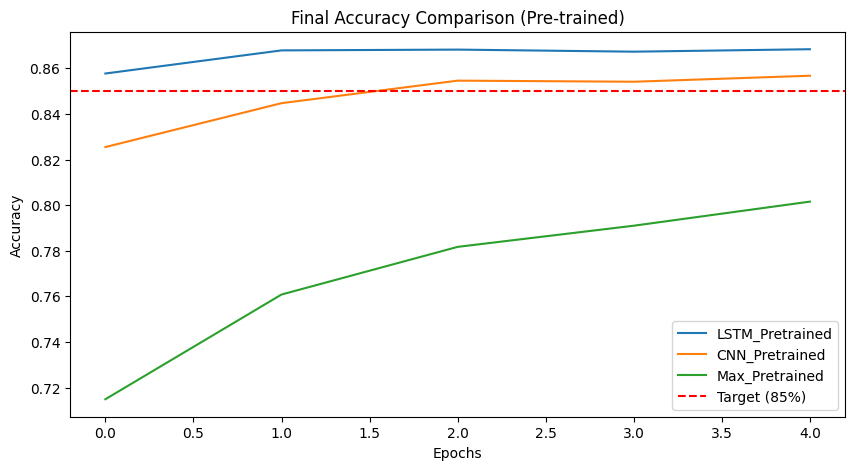

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for history, name in zip(final_histories, final_names):
    plt.plot(history['val_acc'], label=f'{name}')

plt.axhline(y=0.85, color='r', linestyle='--', label='Target (85%)')
plt.title('Final Accuracy Comparison (Pre-trained)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

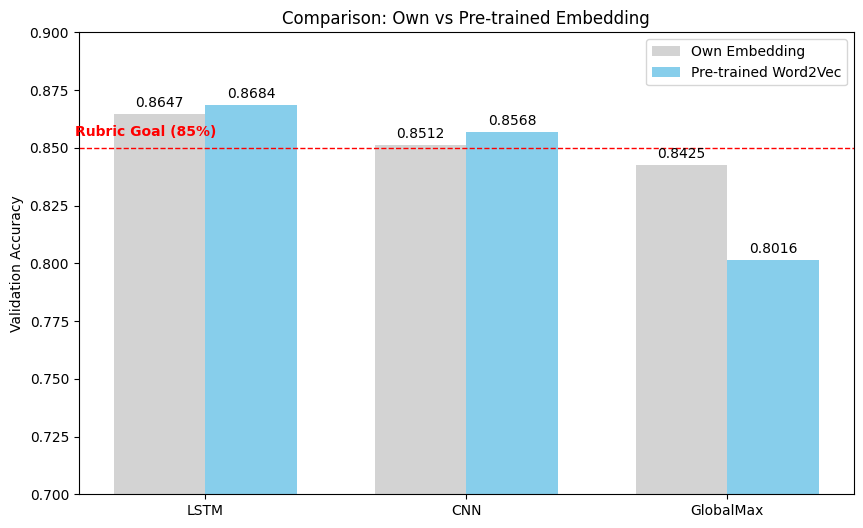

In [136]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 (본인의 결과값으로 자동 추출)
models = ['LSTM', 'CNN', 'GlobalMax']
own_acc = [max(history_lstm['val_acc']), max(history_cnn['val_acc']), max(history_max['val_acc'])]
pre_acc = [max(final_histories[0]['val_acc']), max(final_histories[1]['val_acc']), max(final_histories[2]['val_acc'])]

x = np.arange(len(models))
width = 0.35

# 2. 그래프 그리기
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, own_acc, width, label='Own Embedding', color='lightgray')
rects2 = ax.bar(x + width/2, pre_acc, width, label='Pre-trained Word2Vec', color='skyblue')

# 3. 디자인 및 목표선 추가
ax.set_ylabel('Validation Accuracy')
ax.set_title('Comparison: Own vs Pre-trained Embedding')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# 루브릭 목표선(85%) 추가
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
plt.text(-0.5, 0.855, 'Rubric Goal (85%)', color='red', fontweight='bold')

# 정확도 수치 표시
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.7, 0.9) # 차이를 명확히 보기 위해 범위 조절
plt.show()

회고 : 자체학습한 임베딩과 사전학습 임베딩방식 2가지 방식 모두 OVERFITTING 문제가 보여 EARLY STOPPING을 할 필요가 있어보임..